# 探究INP浓度的日变化

In [1]:
# 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# 数据读取与预处理
df = pd.read_csv(r'D:\Coding\master0_2025\Lanzhou_cfdc\N_INP(202409-202509)v2.0.csv')
df['Date'] = pd.to_datetime(df['Date'])
# 提取时间中的小时信息
df['hour'] = df['Date'].dt.hour
## 将日期设为索引
df = df.set_index('Date')
## 增加1列
def activation_temperature(temp: pd.Series):
    if abs(temp - (-15)) < 2.5:
        return -15
    elif abs(temp - (-20)) < 2.5:
        return -20
    elif abs(temp - (-25)) < 2.5:
        return -25
    elif abs(temp - (-30)) < 2.5:
        return -30
    elif abs(temp - (-35)) < 2.5:
        return -35
    else:
        return np.nan
df['T_a(°C)'] = df['T_inp(°C)'].apply(activation_temperature)
## 解决不显示的问题：中文设置为宋体格式
plt.rcParams['font.family'] = ["Times New Roman", 'SimSun']
## 数据预处理（质量控制）
df_selected = df[df['N_inp_net(#/L)'] > 0]
df_selected = df_selected[df_selected['SS_w'] > 4]# 师兄认为需要剔除 SS_w<4 的数据
# 剔除2024-09-17之前的数据
df_selected = df_selected[df_selected.index >= '2024-09-17']
print(f"总点数量: {df.shape[0]}")
print(f"有效点数量: {df_selected.shape[0]}")
print(f"无效点数量: {df.shape[0] - df_selected.shape[0]}") 

总点数量: 4371
有效点数量: 3095
无效点数量: 1276


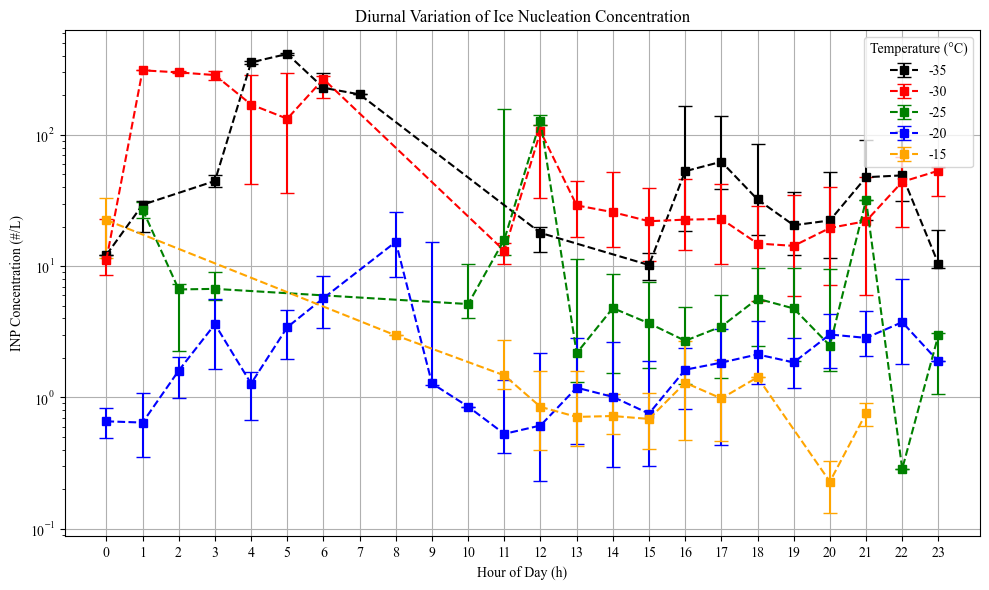

In [3]:
# 按温度分组并计算每个小时的平均冰核浓度和标准差
temps = [-35, -30, -25, -20, -15]
colors = ['black', 'red', 'green', 'blue', 'orange']  # 这里定义每个温度对应的颜色


fig, ax = plt.subplots(figsize=(10, 6)
                       #, dpi=500
                       )
for i , temp in enumerate(temps):

    df_selected = df[df['N_inp_net(#/L)'] > 0]
    df_selected = df_selected[df_selected['SS_w'] > 4]# 师兄认为需要剔除 SS_w<4 的数据
    df_selected = df_selected[df_selected['T_a(°C)'] == temp]
    df_selected = df_selected[df_selected.index >= '2024-09-17']
        
    # 计算每个小时的中位数和MAD
    hourly_data = df_selected.groupby('hour')['N_inp_net(#/L)'].agg(['mean', 'std', 'count', 'median'])

    def mad(data):
        return np.median(np.abs(data - np.median(data)))
    hourly_data['mad'] = df_selected.groupby('hour')['N_inp_net(#/L)'].apply(mad)

    # 计算每个小时的IQR
    def compute_iqr(data):
        Q1 = np.percentile(data, 25)  # 下四分位数
        Q3 = np.percentile(data, 75)  # 上四分位数
        return pd.Series([Q1, Q3], index=['Q1', 'Q3'])
    iqr_data = df_selected.groupby('hour')['N_inp_net(#/L)'].agg([lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])
    iqr_data.columns = ['Q1', 'Q3']
    hourly_data[['Q1', 'Q3']] = iqr_data[['Q1', 'Q3']]

    # 在每个小时的位置添加数据点数量
    #for hour in hourly_data.index:
    #    count = hourly_data.loc[hour, 'count']
        # 在图上显示数据点数量
    #    ax.text(hour, hourly_data.loc[hour, 'median'], f'{count}', ha='center', va='bottom', fontsize=16)

    # 绘制每个温度的平均值和误差条
    ax.errorbar(hourly_data.index, hourly_data['median'], 
                yerr=[hourly_data['median'] - hourly_data['Q1'], hourly_data['Q3'] - hourly_data['median']], 
                label=temp, color=colors[i], marker='s', linestyle='--', capsize=5)

# 添加图表标题和标签
ax.set_title(f'Diurnal Variation of Ice Nucleation Concentration')
ax.set_xlabel('Hour of Day (h)')
ax.set_ylabel(f'INP Concentration (#/L)')
ax.set_xticks(np.arange(0, 24, 1))  # 设置x轴为小时
ax.grid(True)
ax.set_yscale('log')  # 使用对数刻度显示y轴

# 添加图例
ax.legend(title="Temperature (°C)")

# 显示图表
fig.tight_layout()
plt.show()


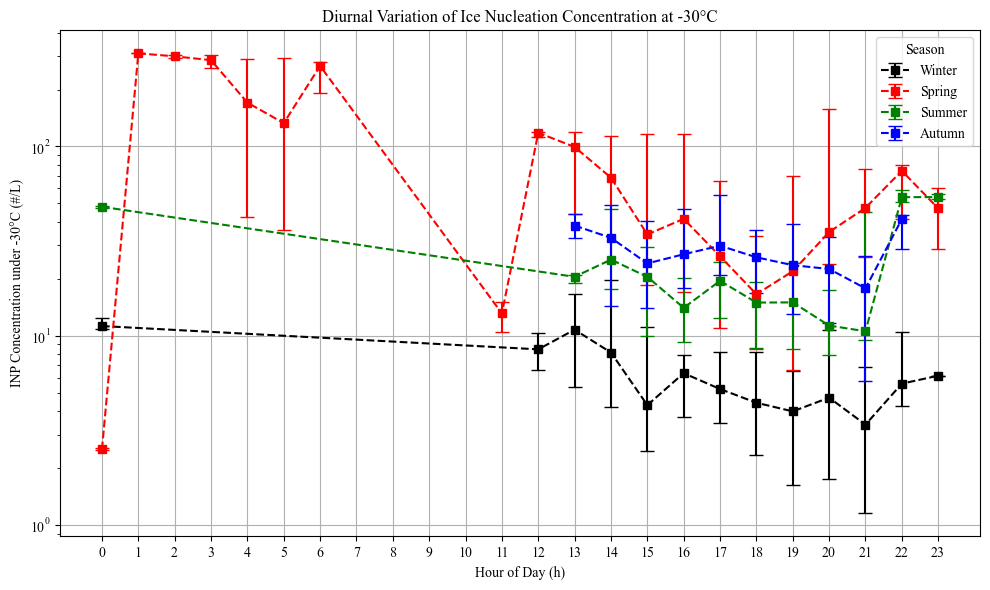

In [5]:
# 按季节分组并计算每个小时的平均冰核浓度和标准差
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']  # 根据数据中的季节命名
colors = ['black', 'red', 'green', 'blue']  # 这里定义每个季节对应的颜色

# 创建一个图形对象
fig, ax = plt.subplots(figsize=(10, 6)
                       #, dpi=500
                       )

temp = -30
for i , season in enumerate(seasons):

    df_selected = df[df['N_inp_net(#/L)'] > 0]
    df_selected = df_selected[df_selected['SS_w'] > 4]# 师兄认为需要剔除 SS_w<4 的数据
    df_selected = df_selected[df_selected['T_a(°C)'] == temp]
    df_selected = df_selected[df_selected['season'] == season]
    df_selected = df_selected[df_selected.index >= '2024-09-17']
    
    # 计算每个小时的中位数和MAD
    hourly_data = df_selected.groupby('hour')['N_inp_net(#/L)'].agg(['mean', 'count', 'median'])

    def mad(data):
        return np.median(np.abs(data - np.median(data)))
    hourly_data['mad'] = df_selected.groupby('hour')['N_inp_net(#/L)'].apply(mad)

    # 计算每个小时的下四分位数 (Q1) 和上四分位数 (Q3)
    def compute_iqr(data):
        Q1 = np.percentile(data, 25)  # 下四分位数
        Q3 = np.percentile(data, 75)  # 上四分位数
        return pd.Series([Q1, Q3], index=['Q1', 'Q3'])
    iqr_data = df_selected.groupby('hour')['N_inp_net(#/L)'].agg([lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])
    iqr_data.columns = ['Q1', 'Q3']
    hourly_data[['Q1', 'Q3']] = iqr_data[['Q1', 'Q3']]
    # 在每个小时的位置添加数据点数量
    #for hour in hourly_data.index:
    #    count = hourly_data.loc[hour, 'count']
        # 在图上显示数据点数量
    #    ax.text(hour, hourly_data.loc[hour, 'median'], f'{count}', ha='center', va='bottom', fontsize=16)

    # 绘制每个季节的平均值和误差条
    ax.errorbar(hourly_data.index, hourly_data['median'],
                yerr=[hourly_data['median'] - hourly_data['Q1'], hourly_data['Q3'] - hourly_data['median']], 
                label=season, color=colors[i], marker='s', linestyle='--', capsize=5)

# 添加图表标题和标签
ax.set_title(f'Diurnal Variation of Ice Nucleation Concentration at {temp}°C')
ax.set_xlabel('Hour of Day (h)')
ax.set_ylabel(f'INP Concentration under {temp}°C (#/L)')
ax.set_xticks(np.arange(0, 24, 1))  # 设置x轴为小时
ax.grid(True)
ax.set_yscale('log')  # 使用对数刻度显示y轴

# 添加图例
ax.legend(title="Season")

# 显示图表
fig.tight_layout()
plt.show()
